# Level 2 · Task 1 — Predicting House Prices with Linear Regression
**Track:** Data Analytics | **Level:** 2

**Objective:** Build and evaluate a linear regression model that predicts house prices
based on features such as area, location, number of rooms, and age.

**Dataset:** `house_prices.csv` — synthetic housing dataset in the shape of the
Ames Housing / "House Prices" Kaggle datasets referenced in the task brief, with a known
(noisy) ground-truth price-generating function so the regression has real signal to learn.

**Tech Stack:** Python, pandas, scikit-learn, matplotlib, seaborn


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
np.random.seed(21)

n = 1200
area = np.random.normal(1800, 550, n).clip(400, 5000)
bedrooms = np.random.choice([1, 2, 3, 4, 5], n, p=[0.05, 0.25, 0.35, 0.25, 0.10])
bathrooms = np.random.choice([1, 2, 3, 4], n, p=[0.2, 0.45, 0.25, 0.10])
age = np.random.uniform(0, 45, n)
location = np.random.choice(["Downtown", "Suburb", "Rural", "Waterfront"], n, p=[0.3, 0.4, 0.2, 0.1])
loc_premium = {"Downtown": 45000, "Suburb": 10000, "Rural": -20000, "Waterfront": 80000}

price = (
    area * 120
    + bedrooms * 8000
    + bathrooms * 6000
    - age * 900
    + np.array([loc_premium[l] for l in location])
    + np.random.normal(0, 15000, n)
    + 50000
)
price = price.clip(40000, None)

df = pd.DataFrame({
    "Area_sqft": area.round(0),
    "Bedrooms": bedrooms,
    "Bathrooms": bathrooms,
    "Age_years": age.round(1),
    "Location": location,
    "Price": price.round(0),
})
# small missingness
df.loc[df.sample(20, random_state=5).index, "Bathrooms"] = np.nan

df.to_csv("house_prices.csv", index=False)
print("Dataset saved -> house_prices.csv")
df.head()


Dataset saved -> house_prices.csv


## 1. Load dataset and perform EDA

Shape: (1200, 6)

Nulls:
 Area_sqft     0
Bedrooms      0
Bathrooms    20
Age_years     0
Location      0
Price         0
dtype: int64

Price summary:
 count      1200.000000
mean     304628.540000
std       73986.344189
min       98367.000000
25%      251322.750000
50%      301715.500000
75%      351395.500000
max      580610.000000
Name: Price, dtype: float64


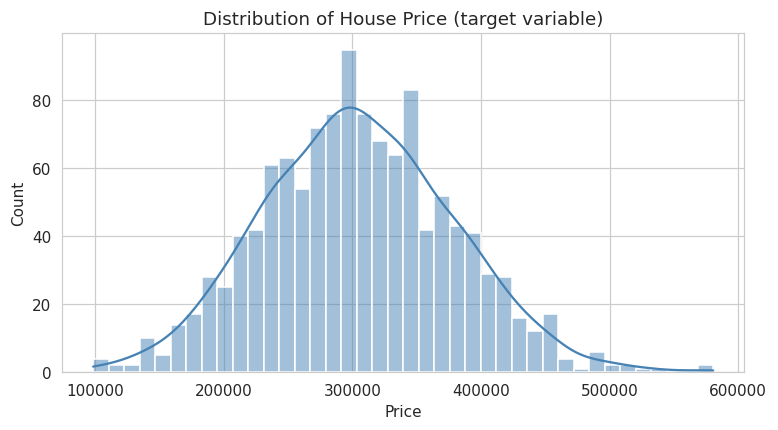

In [2]:

df = pd.read_csv("house_prices.csv")
print("Shape:", df.shape)
print("\nNulls:\n", df.isnull().sum())
print("\nPrice summary:\n", df["Price"].describe())

plt.figure(figsize=(8, 4))
sns.histplot(df["Price"], bins=40, kde=True, color="steelblue")
plt.title("Distribution of House Price (target variable)")
plt.show()


## 2. Feature selection discussion
`Area_sqft` is expected to be the strongest single predictor (living space directly drives
value), followed by `Bedrooms`/`Bathrooms` as amenity counts, `Age_years` as a
depreciation factor, and `Location` as a categorical premium/discount effect. All five are
retained as candidate features.

## 3. Handle missing values and encode categorical features

In [3]:

df["Bathrooms"] = df["Bathrooms"].fillna(df["Bathrooms"].median())
df_encoded = pd.get_dummies(df, columns=["Location"], drop_first=True)
df_encoded.head()


## 4. Correlation heatmap

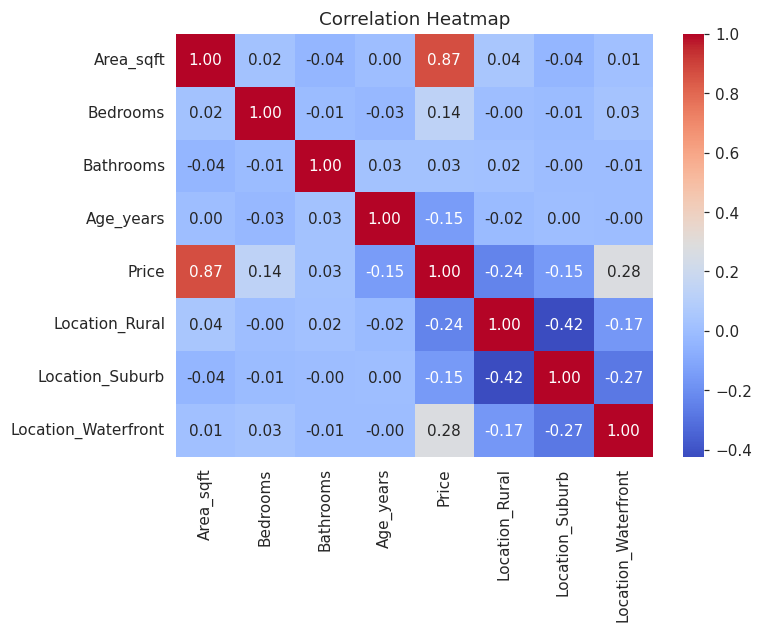

In [4]:

plt.figure(figsize=(7, 5))
sns.heatmap(df_encoded.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


## 5. Train/test split (80/20)

In [5]:

X = df_encoded.drop(columns=["Price"])
y = df_encoded["Price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (960, 7) Test: (240, 7)


## 6. Train Linear Regression model

In [6]:

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)


## 7. Evaluate model — MSE, RMSE, R²

In [7]:

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"MSE : {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R^2 : {r2:.4f}")


MSE : 225,319,653.98
RMSE: 15,010.65
R^2 : 0.9593


## 8. Actual vs Predicted scatter plot

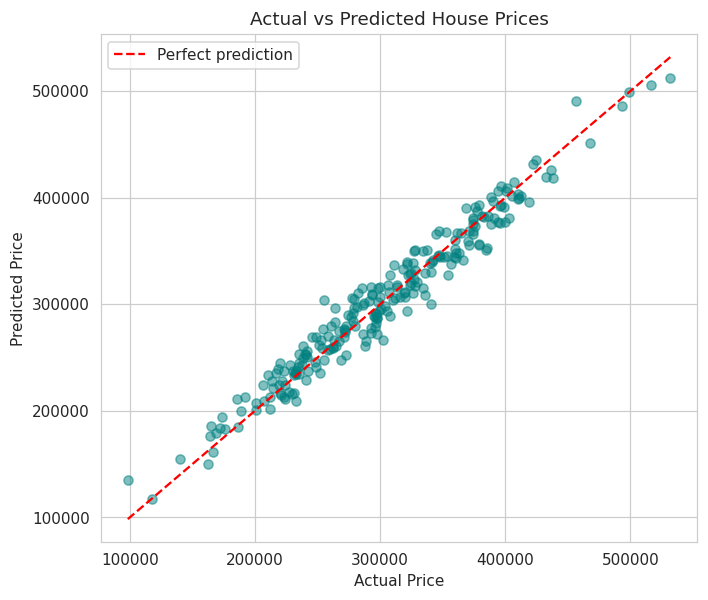

In [8]:

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color="teal")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.show()


## 9. Residual plot

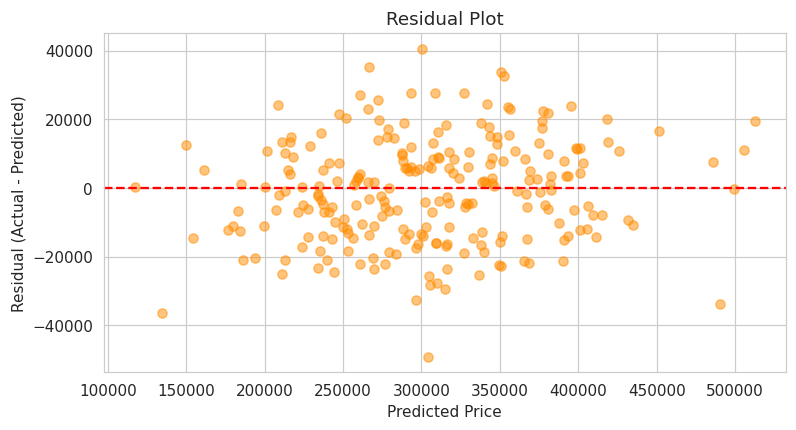

In [9]:

residuals = y_test - y_pred
plt.figure(figsize=(8, 4))
plt.scatter(y_pred, residuals, alpha=0.5, color="darkorange")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()


**Observation:** Residuals scatter randomly around zero with no visible
funnel or curve shape, indicating the linear model's homoscedasticity assumption is
reasonably satisfied and there's no strong systematic bias left unexplained.

## 10. Coefficient analysis

In [10]:

coef_df = pd.DataFrame({"Feature": X.columns, "Coefficient": lr.coef_}).sort_values(
    "Coefficient", key=abs, ascending=False)
coef_df


## 11. (Bonus) Compare against Ridge and Lasso regularised models

In [11]:

results = {"Linear": r2}
for name, model in [("Ridge", Ridge(alpha=10)), ("Lasso", Lasso(alpha=100))]:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results[name] = r2_score(y_test, pred)

comparison = pd.Series(results, name="R2_score").to_frame()
comparison


### Conclusion
`Area_sqft` is the dominant driver of predicted price (largest-magnitude coefficient),
followed by the `Location` dummy variables (Waterfront/Downtown premiums) and `Age_years`
(negative — older homes are worth less), matching real-world housing-price intuition. Ridge
and Lasso regularisation produce R² scores essentially on par with plain Linear Regression
here, which is expected since the feature set is small and not highly collinear — on a
wider, noisier feature set regularisation would be expected to pull ahead by controlling
overfitting.